In [1]:
###### This code is to track all blocking events ######
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import datetime as dt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd
import cv2
import copy
import matplotlib.path as mpath
import pickle
import glob
from netCDF4 import Dataset
from skimage import feature, segmentation, measure
import sys
from collections import defaultdict

### A function to calculate distance between two grid points on earth ###
from math import radians, cos, sin, asin, sqrt
 
# 00 function --------------------------------

regions = ["ATL", "NP", "SP"]
seasons = [ "ALL", "DJF", "JJA"]
seasonsmonths = [[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], [12, 1, 2], [6, 7, 8]]
blkTypes = ["Ridge", "Trough", "Dipole"]
cycTypes = ["AC", "CC"]

def Region_ERA(regionname): 
    if regionname == "ATL": 
        lat_min, lat_max, lon_min, lon_max = 45, 75, 300, 60
    elif regionname == "NP": 
        lat_min, lat_max, lon_min, lon_max = 40, 70, 130, 250
    elif regionname == "SP": 
        lat_min, lat_max, lon_min, lon_max = -75, -45, 180, 300
    return lat_min, lat_max, lon_min, lon_max

def haversine(lon1, lat1, lon2, lat2): # 
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # transform decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
 
    # haversine equation
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # earth radius
    return c * r * 1000

def findClosest(lati, latids):

    if isinstance(lati, np.ndarray):  # if lat is an array
        closest_indices = []
        for l in lati:  
            diff = np.abs(l - latids)
            closest_idx = np.argmin(diff) 
            closest_indices.append(closest_idx)
        return closest_indices
    else:
        # if lat is a single value
        diff = np.abs(lati - latids)
        return np.argmin(diff) 


In [2]:
datasets = ["ERA5", "MERRA2", "JRA3Q"]

OUT_DIR_List = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q"
}
yearnameList = {
    "ERA5": "1979_2025",
    "MERRA2": "1980_2025",
    "JRA3Q": "1979_2025"
}
timerefFile = {
    "ERA5": "/scratch/bell/hu1029/Data/processed/ERA5_Z500_6hr_1979_2025_1dg.nc",
    "MERRA2": "/scratch/bell/hu1029/Data/processed/MERRA2_Z500_6hr_1980_2025_1dg.nc",
    "JRA3Q": "/scratch/bell/hu1029/Data/processed/JRA3Q_Z500_6hr_1979_2025_1dg.nc"
}
latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lat_1979_2025_6hr.npy"
}
lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lon_1979_2025_6hr.npy"
}
TRACK_latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lat_1979_2025_6hr.npy"
}
TRACK_lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lon_1979_2025_6hr.npy"
}

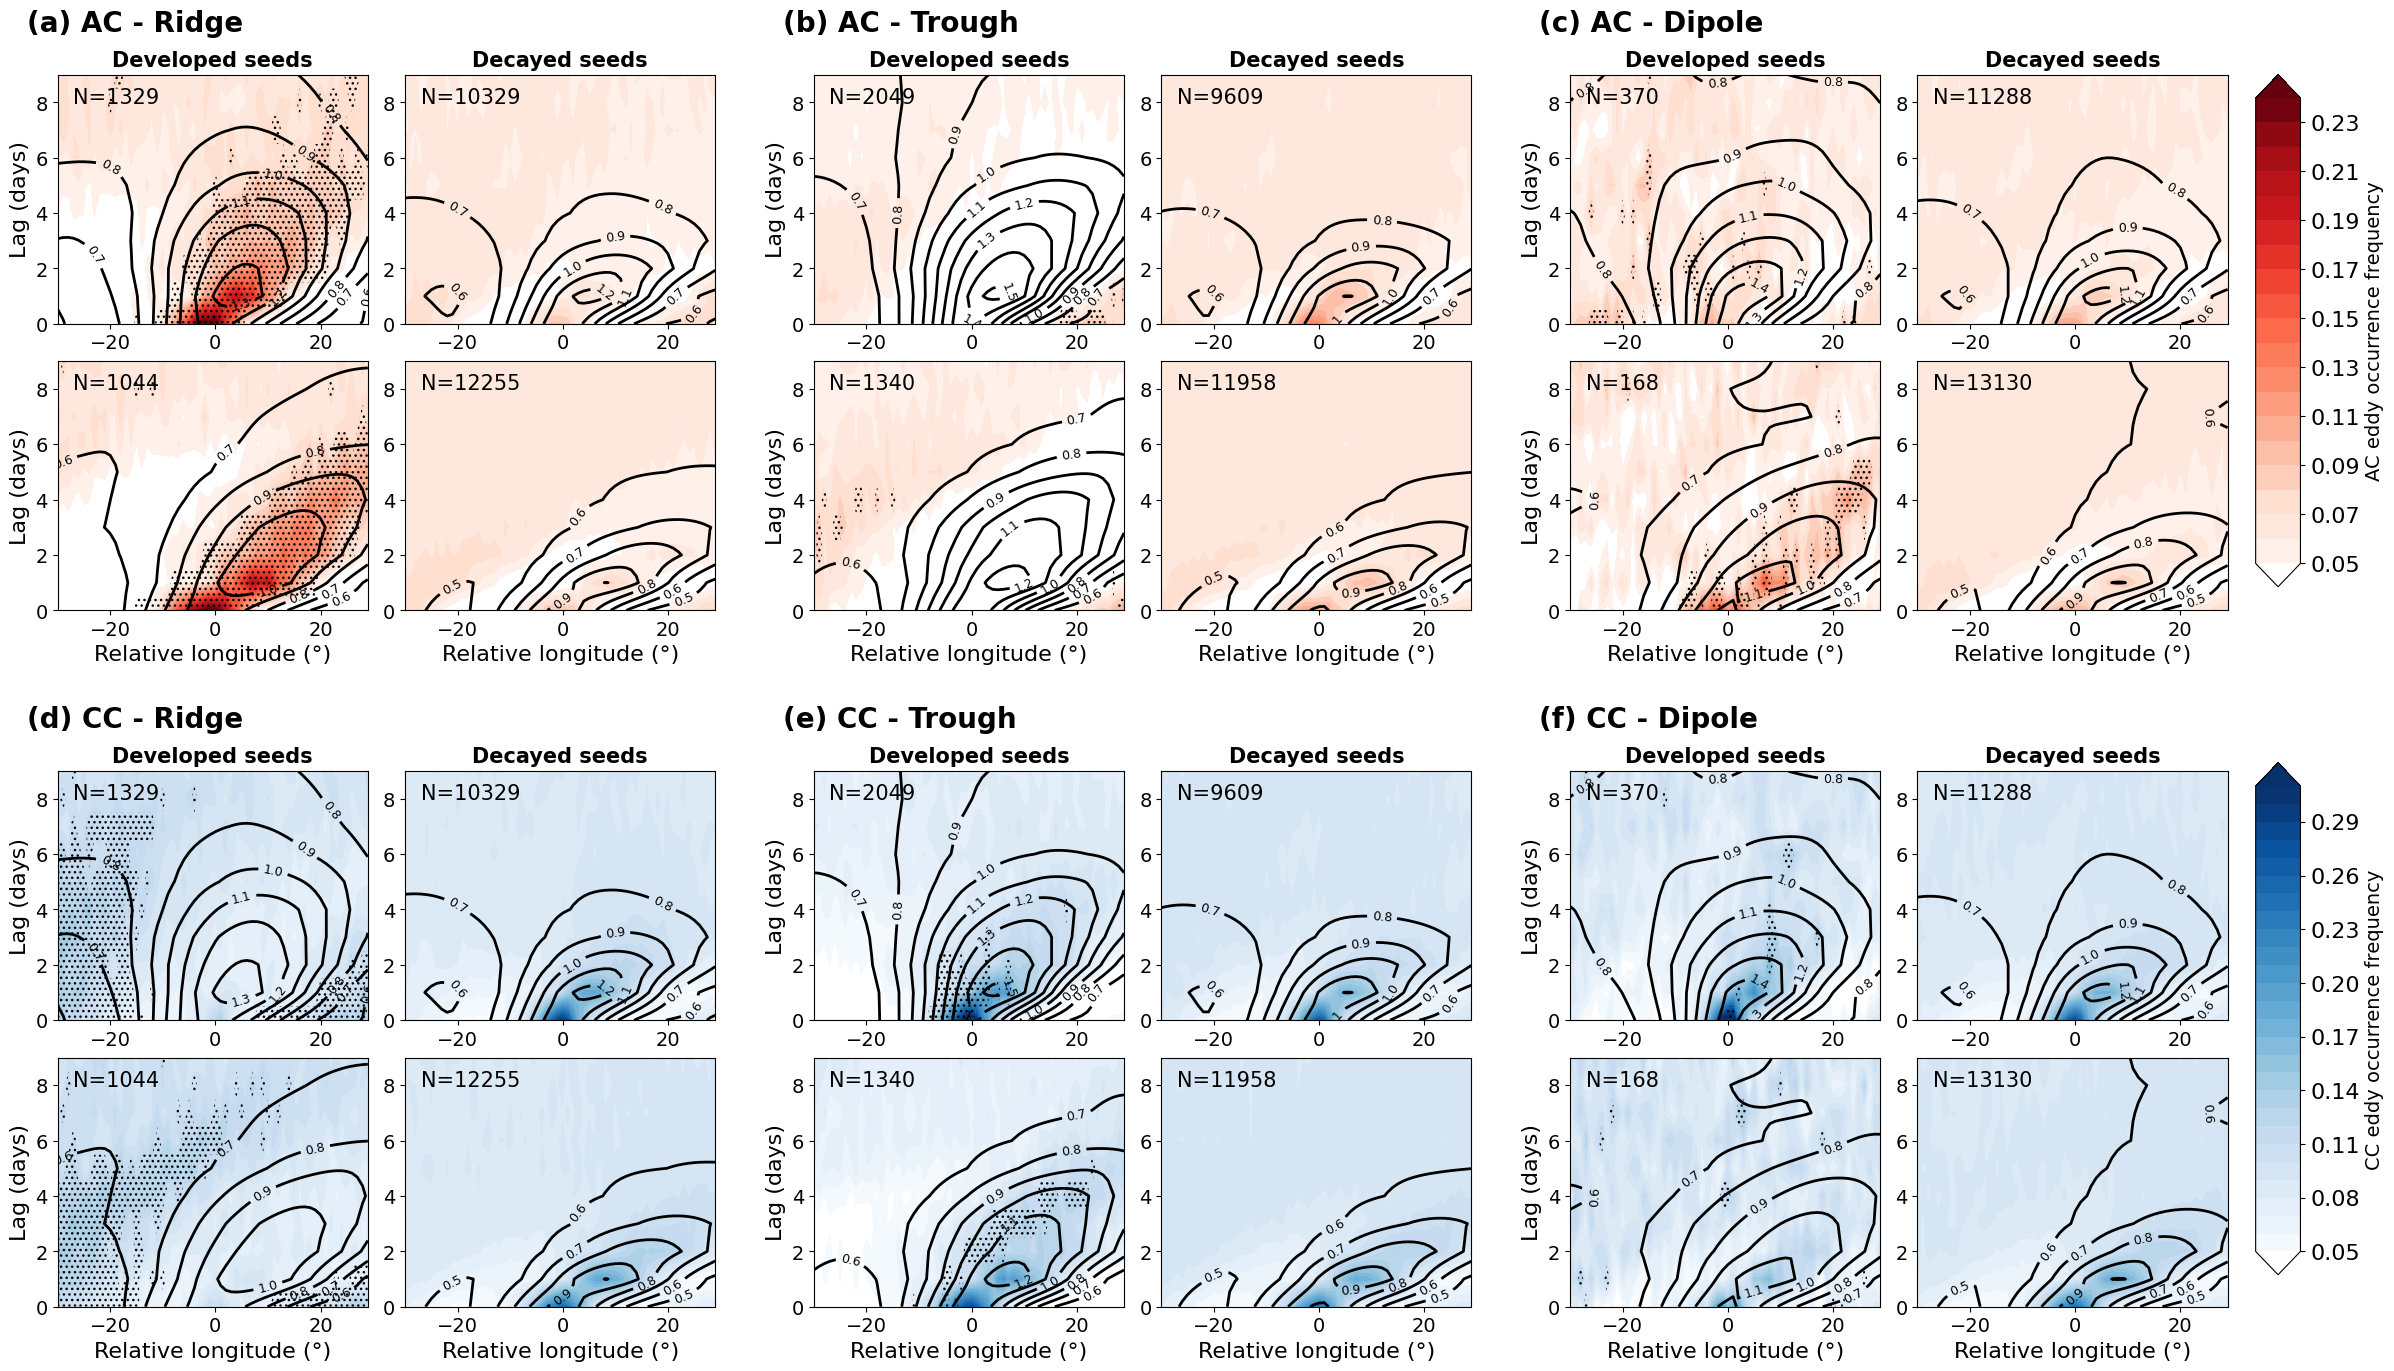

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle

lonarr = np.arange(-30, 30)
lagarr = np.arange(0, 10)

levels_fill = np.arange(0.05, 0.25, 0.01)
levels_cont = np.arange(0, 1.8, 0.1)

cmap = plt.get_cmap('Reds').copy()
cmap.set_under('white')

datasets = ["ERA5", "MERRA2", "JRA3Q"]
hemis = ['NH', 'SH']
situations = ['Developed', 'Decayed']

trackTypes = ['AC', 'CC']
blktype_list = [1, 2, 3]
blktype_names = {1: 'Ridge', 2: 'Trough', 3: 'Dipole'}

panel_order = [
    ('NH', 'Developed'),
    ('NH', 'Decayed'),
    ('SH', 'Developed'),
    ('SH', 'Decayed')
]

fig = plt.figure(figsize=(28, 16))

outer = gridspec.GridSpec(
    nrows=2, ncols=3,
    hspace=0.3, wspace=0.15
)

cs_row = {}

for row, trackType in enumerate(trackTypes):

    # choose colormap by row

    if row == 0:
        cmap_use = plt.get_cmap('Reds').copy()

    else:
        cmap_use = plt.get_cmap('Blues').copy()
        levels_fill = np.arange(0.05, 0.32, 0.01)
    cmap_use.set_under('white')

    for col, blktype in enumerate(blktype_list):

        mean_lwa = {}
        mean_track = {}
        mean_count = {}
        track_by_dataset = {}

        for kk in hemis:
            for situation in situations:
                lwa_list = []
                track_list = []
                count_list = []

                for dtname in datasets:
                    OUTDIR = OUT_DIR_List[dtname]

                    centeredComp_latavg = np.load(
                        f'{OUTDIR}/{dtname}_{kk}_{blktype}_centeredComp_latavg_{situation}.npy'
                    )

                    centeredCompTrack_latavg = np.load(
                        f'{OUTDIR}/{dtname}_{kk}_{blktype}_{trackType}_centeredCompTrack_latavg_{situation}.npy'
                    )

                    with open(
                        f'{OUTDIR}/{dtname}_{kk}_{blktype}_{situation}_targetindices.pkl',
                        'rb'
                    ) as f:
                        targetindices = pickle.load(f)

                    lwa_list.append(centeredComp_latavg)
                    track_list.append(centeredCompTrack_latavg)
                    count_list.append(len(targetindices))

                    track_by_dataset[(dtname, kk, situation)] = centeredCompTrack_latavg

                mean_lwa[(kk, situation)] = np.nanmean(np.stack(lwa_list, axis=0), axis=0)
                mean_track[(kk, situation)] = np.nanmean(np.stack(track_list, axis=0), axis=0)
                mean_count[(kk, situation)] = np.nanmean(count_list)

        # ----- build agreement masks -----
        mask_agree = {}

        for kk in hemis:
            agree_list = []
            for dtname in datasets:
                dev = track_by_dataset[(dtname, kk, 'Developed')]
                dec = track_by_dataset[(dtname, kk, 'Decayed')]

                agree_this_dataset = (dec > 0) & (dev >= 1.2 * dec)
                agree_list.append(agree_this_dataset)

            mask_agree[kk] = np.logical_and.reduce(agree_list)

        inner = gridspec.GridSpecFromSubplotSpec(
            2, 2,
            subplot_spec=outer[row, col],
            hspace=0.15, wspace=0.12
        )

        axes_inner = []

        for p, (kk, situation) in enumerate(panel_order):

            ax = fig.add_subplot(inner[p // 2, p % 2])
            axes_inner.append(ax)

            cs = ax.contourf(
                lonarr, lagarr, mean_track[(kk, situation)],
                levels=levels_fill, cmap=cmap_use, extend='both'
            )

            cs_row[trackType] = cs

            cs2 = ax.contour(
                lonarr, lagarr, mean_lwa[(kk, situation)],
                colors='black', linewidths=2, levels=levels_cont
            )
            ax.clabel(cs2, inline=True, fontsize=9, fmt='%1.1f')

            if situation == 'Developed':
                hatch_mask = mask_agree[kk].astype(int)

                ax.contourf(
                    lonarr, lagarr, hatch_mask,
                    levels=[0.5, 1.5],
                    colors='none',
                    hatches=['...'],
                )

            # ax.set_title(f'{kk} - {situation}', fontsize=12, pad=6)
            ax.grid(False)
            ax.tick_params(axis='both', which='major', labelsize=14)

            count = int(mean_count[(kk, situation)])
            ax.text(
                0.05, 0.95, f'N={count}',
                transform=ax.transAxes,
                fontsize=15, color='black',
                verticalalignment='top',
                horizontalalignment='left'
            )

        axes_inner[2].set_xlabel('Relative longitude (°)', fontsize=16)
        axes_inner[3].set_xlabel('Relative longitude (°)', fontsize=16)
        axes_inner[0].set_ylabel('Lag (days)', fontsize=16)
        axes_inner[2].set_ylabel('Lag (days)', fontsize=16)

        axes_inner[0].set_title("Developed seeds", fontsize=15, pad=6, fontweight='bold')
        axes_inner[1].set_title("Decayed seeds", fontsize=15, pad=6, fontweight='bold')

        labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
        idx = row * 3 + col
        axes_inner[0].text(
            -0.1, 1.15,
            f'{labels[idx]} {trackType} - {blktype_names[blktype]}',
            transform=axes_inner[0].transAxes,
            fontsize=20,
            fontweight='bold',
            ha='left',
            va='bottom'
        )

# colorbar for AC row
cbar_ax1 = fig.add_axes([0.91, 0.56, 0.016, 0.32]) # [left, bottom, width, height]
cbar1 = fig.colorbar(cs_row['AC'], cax=cbar_ax1)
cbar1.set_label('AC eddy occurrence frequency', fontsize=14)
cbar1.ax.tick_params(labelsize=16)

# colorbar for CC row
cbar_ax2 = fig.add_axes([0.91, 0.13, 0.016, 0.32]) # [left, bottom, width, height]
cbar2 = fig.colorbar(cs_row['CC'], cax=cbar_ax2)
cbar2.set_label('CC eddy occurrence frequency', fontsize=14)
cbar2.ax.tick_params(labelsize=16)

plt.savefig('./FINAL_figures/Nature_ExtendedFig4.png', dpi=300, bbox_inches='tight')
plt.show()